In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import load_iris
data=load_iris()
X=data.data
y=data.target

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
X_train.shape

(120, 4)

In [5]:
X_test.shape

(30, 4)

In [6]:
## Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)
print("Decision Tree:",accuracy_score(y_test,y_pred_dt))

Decision Tree: 1.0


In [7]:
## random Forest 
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
print("random Forest:",accuracy_score(y_test,y_pred_rf))

random Forest: 1.0


In [8]:
## SVM
from sklearn.svm import SVC
svm=SVC(kernel='rbf')
svm.fit(X_train,y_train)
y_pred_svm=svm.predict(X_test)
print("SVM:",accuracy_score(y_test,y_pred_svm))

SVM: 1.0


In [9]:
## Adabost 
from sklearn.ensemble import AdaBoostClassifier
adb=AdaBoostClassifier(n_estimators=50)
adb.fit(X_train,y_train)
y_pred_adb=adb.predict(X_test)
print("AdaBoost:",accuracy_score(y_test,y_pred_adb))

AdaBoost: 0.9333333333333333


In [10]:
## Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting: 1.0


In [11]:
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

XGBoost: 1.0


In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [16]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
y_pred_knn=knn.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred_knn))
print(confusion_matrix(y_test,y_pred_knn))
print(classification_report(y_test,y_pred_knn))

1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [19]:
for k in range(1,11):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred_knn=knn.predict(X_test)
    print(f"{k},Accuracy={accuracy_score(y_test,y_pred_knn)}")

1,Accuracy=1.0
2,Accuracy=1.0
3,Accuracy=1.0
4,Accuracy=1.0
5,Accuracy=1.0
6,Accuracy=1.0
7,Accuracy=1.0
8,Accuracy=1.0
9,Accuracy=1.0
10,Accuracy=1.0


In [24]:
## Kmeans
from sklearn.datasets import make_blobs
X,_=make_blobs(n_samples=300,centers=4,random_state=42)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
inertia,sil=[],[]
k_range=range(2,11)
for k in k_range:
    km=KMeans(n_clusters=k,init='k-means++',n_init=10,random_state=42)
    labels=km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled,labels))
best_k=k_range[np.argmax(sil)]
print(f"Best K by Silhouette:{best_k}")

Best K by Silhouette:4


In [25]:
final_km=KMeans(n_clusters=best_k,init="k-means++",n_init=10,random_state=42)
final_km.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [27]:
print(f"Inertia:{final_km.inertia_:.2f}")
print(f"Cluster:{np.bincount(final_km.labels_)}")
print(f"Centroids:{final_km.cluster_centers_.shape}")

Inertia:17.47
Cluster:[76 75 75 74]
Centroids:(4, 2)


In [30]:
## Ridge
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge,Lasso,ElasticNet
from sklearn.metrics import r2_score
import numpy as np
data=load_diabetes()
X=data.data
y=data.target

In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [34]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
y_pred_rid=ridge.predict(X_test)
print("Ridge:",r2_score(y_test,y_pred_rid))

Ridge: 0.45414652070698225


In [36]:
lasso=Lasso(alpha=0.1)
lasso.fit(X_train,y_train)
y_pred_las=lasso.predict(X_test)
print("lasso :",r2_score(y_test,y_pred_las))

lasso : 0.45554139902790414


In [38]:
elastic=ElasticNet(alpha=0.1,l1_ratio=0.5)
elastic.fit(X_train,y_train)
y_pred_ela=elastic.predict(X_test)
print("Elastic net:",r2_score(y_test,y_pred_ela))

Elastic net: 0.45896958196783777


In [39]:
print("Ridge Coefficients:\n", ridge.coef_)
print("Lasso Coefficients:\n", lasso.coef_)
print("ElasticNet Coefficients:\n", elastic.coef_)

Ridge Coefficients:
 [  1.80734179 -11.44818951  25.73269892  16.73429974 -34.67195409
  17.05307485   3.36991411  11.76426044  31.3783838    2.45813922]
Lasso Coefficients:
 [  1.73045056 -11.31635911  25.82462699  16.64425156 -29.35841191
  13.27584411   0.5479479   10.23616805  29.63282611   2.39347521]
ElasticNet Coefficients:
 [  1.90157093 -10.62268037  25.23595974  15.9999032   -8.89299905
  -2.07883535  -7.81607048   7.70768758  20.99806392   3.1519138 ]


In [40]:
print("Lasso zero count:", np.sum(lasso.coef_ == 0))
print("ElasticNet zero count:", np.sum(elastic.coef_ == 0))

Lasso zero count: 0
ElasticNet zero count: 0


In [41]:
## Linear regression
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
data = load_diabetes()
X = data.data
y = data.target

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [46]:
y_pred = model.predict(X_test)

In [47]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.45260276297191915
MSE: 2900.193628493483


In [48]:
## Logistics Regression
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [49]:
iris = load_iris()
X = iris.data
y = iris.target

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [52]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [53]:
y_pred = log_model.predict(X_test)

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [58]:
## DBScan 
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [60]:
X, _ = make_moons(n_samples=300, noise=0.05)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

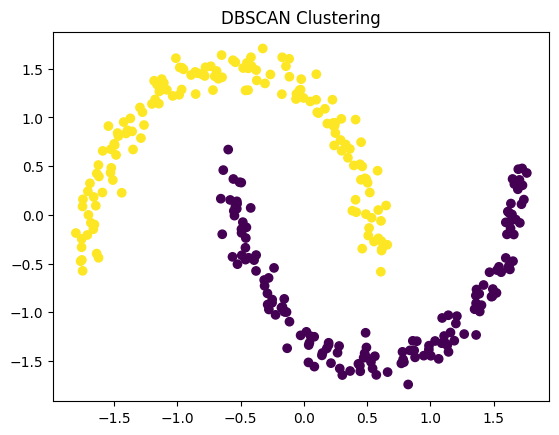

In [63]:
dbscan=DBSCAN(eps=0.3,min_samples=5)
labels=dbscan.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=labels)
plt.title("DBSCAN Clustering")
plt.show()

In [64]:
## Naive Bayes
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

In [65]:
iris=load_iris()
X=iris.data
y=iris.target

In [68]:
import pandas as pd
y.shape

(150,)

In [69]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [72]:
pd.Series(y).value_counts()

0    50
1    50
2    50
Name: count, dtype: int64

In [74]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=GaussianNB()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classiification report:\n",classification_report(y_test,y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classiification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

